In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

In [19]:
"""
0 → T-shirt/top
1 → Trouser
2 → Pullover
3 → Dress
4 → Coat
5 → Sandal
6 → Shirt
7 → Sneaker
8 → Bag
9 → Ankle boot
"""

'\n0 → T-shirt/top\n1 → Trouser\n2 → Pullover\n3 → Dress\n4 → Coat\n5 → Sandal\n6 → Shirt\n7 → Sneaker\n8 → Bag\n9 → Ankle boot\n'

In [20]:
mnist_data = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = mnist_data.load_data()

In [21]:
print(np.unique(train_labels)) # there are 10 classes in the dataset
print(train_images.shape) # there are 60000 images in the training set and each image is 28x28 pixels
print(test_images.shape) # there are 10000 images in the test set and each image is 28x28 pixels

[0 1 2 3 4 5 6 7 8 9]
(60000, 28, 28)
(10000, 28, 28)


In [22]:
train_images[0] # the first image in the training set in gray scale (28x28 pixels) with pixel values between 0 and 255

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

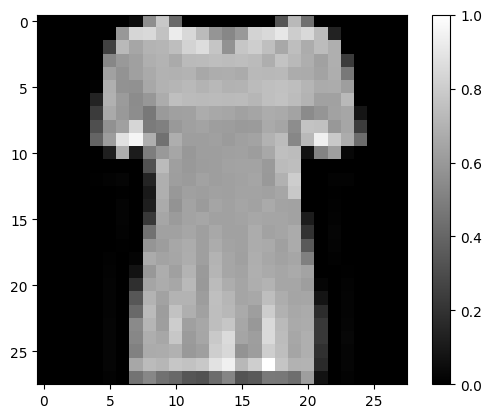

In [34]:
plt.imshow(train_images[10],cmap='gray')
plt.colorbar()



In [24]:
# Img Normalization
train_images = train_images / 255.0
test_images = test_images / 255.0
"""
or we can use:
normalization #2:
train_images = tf.keras.utils.normalize(train_images, axis=1) 
test_images = tf.keras.utils.normalize(test_images, axis=1)   
"""

'\nor we can use:\nnormalization #2:\ntrain_images = tf.keras.utils.normalize(train_images, axis=1) \ntest_images = tf.keras.utils.normalize(test_images, axis=1)   \n'

In [25]:
train_images[0]# the first image in the training set after normalization with pixel values between 0 and 1

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

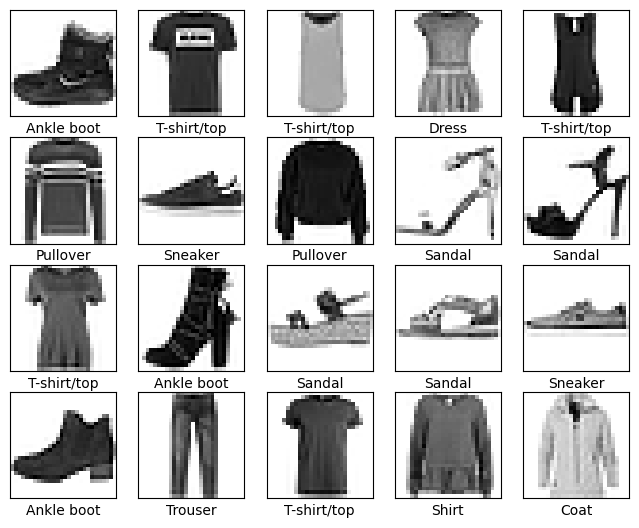

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 
               'Dress', 'Coat', 'Sandal', 'Shirt', 
               'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(8,8))
for i in range(20):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary) # display the image in binary color map (black and white)
    plt.xlabel(class_names[train_labels[i]])

#### **Building the model**
___

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # this layer converts the 2D image (28x28) into a 1D array of 784 pixels cuz Dense understand only 1D array
    keras.layers.Dense(128, activation=tf.nn.relu), # this layer is a fully connected layer with 128 neurons and ReLU activation function
    keras.layers.Dense(10, activation=tf.nn.softmax) # this layer is a fully connected layer with 10 neurons (one for each class) 
]) # and softmax activation function to output the class probabilities

"""
Input Image (28x28)
        ↓
Flatten → 784
        ↓
Dense (128 neurons + ReLU)
        ↓
Dense (10 neurons + Softmax)
        ↓
Prediction (class probability)
"""

# Dense = fully connected layer
# ReLU = Rectified Linear Unit activation function
# Softmax = activation function that converts the output of the last layer into a probability distribution over the classes


c:\Users\e\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


'\nInput Image (28x28)\n        ↓\nFlatten → 784\n        ↓\nDense (128 neurons + ReLU)\n        ↓\nDense (10 neurons + Softmax)\n        ↓\nPrediction (class probability)\n'

In [28]:
# Model Compilation
model.compile(optimizer=tf.optimizers.Adam(), # this optimizer is used to minimize the loss function and update the weights of the model
              loss='sparse_categorical_crossentropy', # this loss function is used for multi-class classification problems
              metrics=['accuracy']) # evaluate the performance of the model

In [29]:
model.fit(train_images, train_labels, epochs=10) 

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8252 - loss: 0.4966
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8648 - loss: 0.3763
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8772 - loss: 0.3380
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8859 - loss: 0.3136
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8910 - loss: 0.2960
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8961 - loss: 0.2831
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9003 - loss: 0.2687
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9033 - loss: 0.2590
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9079 - loss: 0.2479
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9083 - loss: 0.2413


#### **Model Evaluation**
___

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8812 - loss: 0.3359
Test accuracy: 0.8812000155448914


#### **Model Prediction**
___

In [ ]:
predictions = model.predict(test_images) # this will output the predicted class probabilities for each image in the test set
print(predictions[0]) # the predicted class probabilities for the first image in the test set


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[4.3598328e-07 2.4259956e-08 8.9919290e-08 1.0577510e-08 1.2642423e-07
 4.9298123e-04 5.4840786e-08 1.2736434e-02 8.4625370e-08 9.8676968e-01]


In [32]:
print("Predicted class:", np.argmax(predictions[0])) # the predicted class for the first image in the test set (the class with the highest probability)
print("True class:", test_labels[0]) # the true class for the first image in the test set

Predicted class: 9
True class: 9


#### **Try The Model**

In [51]:
from PIL import Image
imgs = ["tshirt.png", "bag.png"]

for img in imgs:
    img = Image.open(img)
    img = img.convert('L') # convert the image to grayscale (L mode) because the model was trained on grayscale images
    img = img.resize((28, 28)) # resize the image to 28x28 pixels because the model was trained on images of this size
    img = np.array(img) # convert the image to a numpy array so we can feed it to the model
    img = img / 255.0 # normalize the image to have pixel values between 0 and 1 because the model was trained on normalized images
    img = 1 - img # invert the image because the model was trained on images with white background and black pixels, but our image has black background and white pixels
    img = np.expand_dims(img, 0) # add an extra dimension to the image to make it a batch of one image (1, 28, 28) because the model expects a batch of images as input

    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])

    print("Predicted class:", predicted_class)
    print("Predicted label:", class_names[predicted_class])
    print("\n","=" * 50, "\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted class: 0
Predicted label: T-shirt/top


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted class: 8
Predicted label: Bag


